# Postie Data Challenge — Exploratory Analysis

This notebook documents the initial data acquisition, validation, and exploratory analysis for the Postie data challenge.

This is preliminary analysis. The goal is not yet to answer the challenge questions directly, but to understand the data before forming explanations or making predictions. I use this notebook to inspect day-to-day sales behavior, check for missing or unusual values, identify potential data quality concerns, and determine whether July 3 appears unusual compared with the rest of the available data.

## Primary Questions in This Notebook

1. What do day-to-day sales patterns look like?
2. Are there missing values, outliers, or unusual records?
3. Are there data issues that may require caution, such as timestamp handling, negative values, or unusually large transactions?
4. Does July 3 appear unusual compared with the other available days?

## Notebook Outputs

Generated charts are saved to `outputs/figures/`, and summary tables are saved to `outputs/tables/`.

In [ ]:
# ------------------------------------------------------------
# Output directories and plotting style
# ------------------------------------------------------------

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np
import datetime

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white", context="talk")

TITLE_STYLE = {
    "fontsize": 20,
    "fontweight": "bold",
    "pad": 18
}

AXIS_LABEL_STYLE = {
    "fontsize": 15,
    "fontweight": "bold",
    "labelpad": 10
}

TARGET_COLOR = "#E06666"   # coral highlight
GREY_COLORS = ["#cfcfcf", "#9f9f9f", "#6f6f6f", "#d9d9d9", "#b5b5b5"]

target_date = pd.to_datetime("2017-07-03").date()

def save_current_figure(filename):
    """
    Save current matplotlib figure to outputs/figures.
    """
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {path}")
    

def save_table(df_table, filename):
    """
    Save dataframe to outputs/tables.
    """
    path = TABLES_DIR / filename
    df_table.to_csv(path, index=False)
    print(f"Saved table: {path}")
    # print(df_table.to_markdown(index=False))

## Plotting Helper Functions

The following helper function standardizes the daily bar charts used throughout the exploratory analysis. In these plots, `2017-07-03` is highlighted while the surrounding days are shown in muted grey tones.

This makes the anomaly date visually easy to identify without overcomplicating each individual plotting cell.


In [204]:
# ------------------------------------------------------------
# Reusable daily bar plot helper
# ------------------------------------------------------------

def plot_daily_bar(
    data,
    y_col,
    title,
    y_label,
    filename,
    money_axis=False,
    value_format="{:,.0f}",
    figsize=(10, 6)
):
    plot_data = data.copy().sort_values("date")
    
    colors = [
        TARGET_COLOR if date == target_date else GREY_COLORS[i % len(GREY_COLORS)]
        for i, date in enumerate(plot_data["date"])
    ]
    
    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_data,
        x="date",
        y=y_col,
        palette=colors,
        hue="date",
        legend=False
    )

    for patch in ax.patches:
        height = patch.get_height()

        if money_axis:
            label = f"${height:,.0f}"
        else:
            label = value_format.format(height)

        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.title(title, **TITLE_STYLE)
    plt.xlabel("Date", **AXIS_LABEL_STYLE)
    plt.ylabel(y_label, **AXIS_LABEL_STYLE)

    if money_axis:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    sns.despine()

    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

## Data Loading and Initial Preparation

After acquiring the raw transaction logs, I load the files into a single pandas dataframe and apply a small amount of initial preparation. The expected fields include transaction timestamp, website and customer identifiers, app version, checkout amount, and the originating URL.

The purpose of this step is to make the dataset usable for analysis without over-cleaning it too early. Because the challenge asks us to identify potential problems in the data, I preserve the original records as much as possible and focus on transparent type conversion, schema validation, and creation of a reusable processed dataset.

In [205]:
import pandas as pd
import requests
import xml.etree.ElementTree as ET
from pathlib import Path

# -----------------------------
# Project paths
# -----------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Expected schema from challenge instructions
columns = [
    "timestamp",
    "website_id",
    "customer_id",
    "app_version",
    "placeholder",
    "checkout_amount",
    "url",
]

# -----------------------------
# Discover files in public S3 bucket
# -----------------------------
bucket_url = "https://s3.amazonaws.com/postie-testing-assets?list-type=2"
response = requests.get(bucket_url)
response.raise_for_status()

root = ET.fromstring(response.text)

# Handle S3 XML namespace flexibly
keys = [
    item.text
    for item in root.iter()
    if item.tag.endswith("Key") and item.text
]

if not keys:
    raise ValueError("No files found in S3 bucket listing. Check bucket URL or response format.")

# -----------------------------
# Download files locally if needed
# -----------------------------
for key in keys:
    url = f"https://postie-testing-assets.s3.amazonaws.com/{key}"
    local_path = DATA_RAW / Path(key).name

    if not local_path.exists():
        file_response = requests.get(url)
        file_response.raise_for_status()
        local_path.write_bytes(file_response.content)

# -----------------------------
# Load all downloaded files
# -----------------------------
raw_files = sorted(
    file for file in DATA_RAW.iterdir()
    if file.is_file() and not file.name.startswith(".")
)

if not raw_files:
    raise ValueError(f"No raw files found in {DATA_RAW}")

dfs = []

for file in raw_files:
    temp = pd.read_csv(
        file,
        header=0,
        sep=None,          # infer delimiter automatically
        engine="python",   # required for sep=None
        compression="infer",
        on_bad_lines="warn"
    )

    # Clean column names in case there is whitespace
    temp.columns = temp.columns.str.strip()

    # Ensure expected columns are present
    missing_cols = [col for col in columns if col not in temp.columns]
    if missing_cols:
        raise ValueError(f"{file.name} is missing expected columns: {missing_cols}")

    # Keep only expected columns, in expected order
    temp = temp[columns].copy()

    # Track source file
    temp["source_file"] = file.name

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
# -----------------------------
# Safety check: remove accidental header-like rows
# -----------------------------
header_like_rows = (
    (df["timestamp"].astype(str).str.lower() == "timestamp") |
    (df["checkout_amount"].astype(str).str.lower() == "checkout_amount") |
    (
        (df["app_version"].astype(str).str.lower() == "app_version") &
        (df["placeholder"].astype(str).str.lower() == "placeholder") &
        (df["url"].astype(str).str.lower() == "url")
    )
)

if header_like_rows.any():
    print(f"Removing {header_like_rows.sum()} header-like rows.")
    df = df[~header_like_rows].copy()

# -----------------------------
# Basic type cleanup
# -----------------------------
# NOTE: The raw transaction logs contain timestamps with mixed timezone information.
# Timestamps are normalized to UTC so records can be compared consistently across files.
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df["website_id"] = pd.to_numeric(df["website_id"], errors="coerce")
df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")
df["checkout_amount"] = pd.to_numeric(df["checkout_amount"], errors="coerce")

# Helpful derived fields for later analysis
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

# -----------------------------
# Save processed data
# -----------------------------
processed_path = DATA_PROCESSED / "transactions_clean.csv"
df.to_csv(processed_path, index=False)

# -----------------------------
# Confirmation
# -----------------------------
print("Data acquired and cleaned successfully.")
print(f"Files loaded: {len(raw_files)}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Missing timestamps: {df['timestamp'].isna().sum()}")
print(f"Missing checkout amounts: {df['checkout_amount'].isna().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Total sales: ${df['checkout_amount'].sum():,.2f}")
print(f"Saved to: {processed_path}")

Data acquired and cleaned successfully.
Files loaded: 3
Rows: 33,188
Columns: 11
Date range: 2017-07-01 00:00:15+00:00 to 2017-07-03 23:59:57+00:00
Missing timestamps: 0
Missing checkout amounts: 0
Duplicate rows: 0
Total sales: $588,850.00
Saved to: c:\Users\melis\Documents\postie-data-science-presentation\data\processed\transactions_clean.csv


In [206]:
# Initial data validation

expected_columns = [
    "timestamp",
    "website_id",
    "customer_id",
    "app_version",
    "placeholder",
    "checkout_amount",
    "url",
    "source_file",
]

validation_summary = {
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": df.duplicated().sum(),
    "timestamp_min": df["timestamp"].min(),
    "timestamp_max": df["timestamp"].max(),
    "total_sales": df["checkout_amount"].sum(),
    "missing_timestamps": df["timestamp"].isna().sum(),
    "missing_checkout_amounts": df["checkout_amount"].isna().sum(),
    "missing_urls": df["url"].isna().sum(),
}

pd.Series(validation_summary)

rows                                            33188
columns                                            11
duplicate_rows                                      0
timestamp_min               2017-07-01 00:00:15+00:00
timestamp_max               2017-07-03 23:59:57+00:00
total_sales                                  588850.0
missing_timestamps                                  0
missing_checkout_amounts                            0
missing_urls                                        0
dtype: object

## Reproducing the Reported July 3 Sales Value

The challenge states that the analyst reported `2017-07-03` sales of **$164,065.00**. I first compute daily sales directly from the cleaned transaction logs to see whether that number can be reproduced.

This section also creates a daily summary with interpretable components of sales:

- total sales
- transaction volume
- average order value
- median order value
- unique customers
- website/app-version coverage

This decomposition matters because a lower daily sales total can be caused by fewer transactions, smaller orders, missing data, or behavior isolated to part of the system.


In [207]:
# ------------------------------------------------------------
# Investigate reported July 3 sales discrepancy
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# Analyst-reported value from the challenge prompt
reported_july_03_sales = 164_065.00
target_date = pd.to_datetime("2017-07-03").date()

# Make sure date fields exist
if "date" not in df.columns:
    df["date"] = df["timestamp"].dt.date

if "hour" not in df.columns:
    df["hour"] = df["timestamp"].dt.hour

if "day_of_week" not in df.columns:
    df["day_of_week"] = df["timestamp"].dt.day_name()

# ------------------------------------------------------------
# Daily summary
# ------------------------------------------------------------

daily_summary = (
    df.groupby("date")
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        min_order_value=("checkout_amount", "min"),
        max_order_value=("checkout_amount", "max"),
        unique_customers=("customer_id", "nunique"),
        unique_websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
        source_files=("source_file", "nunique"),
    )
    .reset_index()
    .sort_values("date")
)

# Add comparison columns
daily_summary["sales_change_vs_prior_day"] = daily_summary["total_sales"].diff()
daily_summary["sales_pct_change_vs_prior_day"] = daily_summary["total_sales"].pct_change()
daily_summary["transaction_change_vs_prior_day"] = daily_summary["transactions"].diff()
daily_summary["transaction_pct_change_vs_prior_day"] = daily_summary["transactions"].pct_change()

# Reproduce July 3 sales
july_03_row = daily_summary[daily_summary["date"] == target_date].copy()

if july_03_row.empty:
    print("No records found for 2017-07-03.")
else:
    computed_july_03_sales = july_03_row["total_sales"].iloc[0]
    difference_from_reported = computed_july_03_sales - reported_july_03_sales
    
    print("July 3 sales check")
    print("------------------")
    print(f"Reported July 3 sales: ${reported_july_03_sales:,.2f}")
    print(f"Computed July 3 sales: ${computed_july_03_sales:,.2f}")
    print(f"Difference: ${difference_from_reported:,.2f}")

daily_summary

July 3 sales check
------------------
Reported July 3 sales: $164,065.00
Computed July 3 sales: $181,583.00
Difference: $17,518.00


,date,transactions,total_sales,average_order_value,median_order_value,min_order_value,max_order_value,unique_customers,unique_websites,app_versions,source_files,sales_change_vs_prior_day,sales_pct_change_vs_prior_day,transaction_change_vs_prior_day,transaction_pct_change_vs_prior_day
0,2017-07-01,9903,223515.0,22.570433,6.0,0.0,55084.0,7372,2,1,1,NaN,NaN,NaN,NaN
1,2017-07-02,11537,183752.0,15.927191,6.0,3.0,55002.0,8168,2,1,2,-39763.0,-0.177899,1634.0,0.165001
2,2017-07-03,11748,181583.0,15.456503,6.0,-12.0,60000.0,8227,2,2,2,-2169.0,-0.011804,211.0,0.018289


Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\daily_total_sales.png


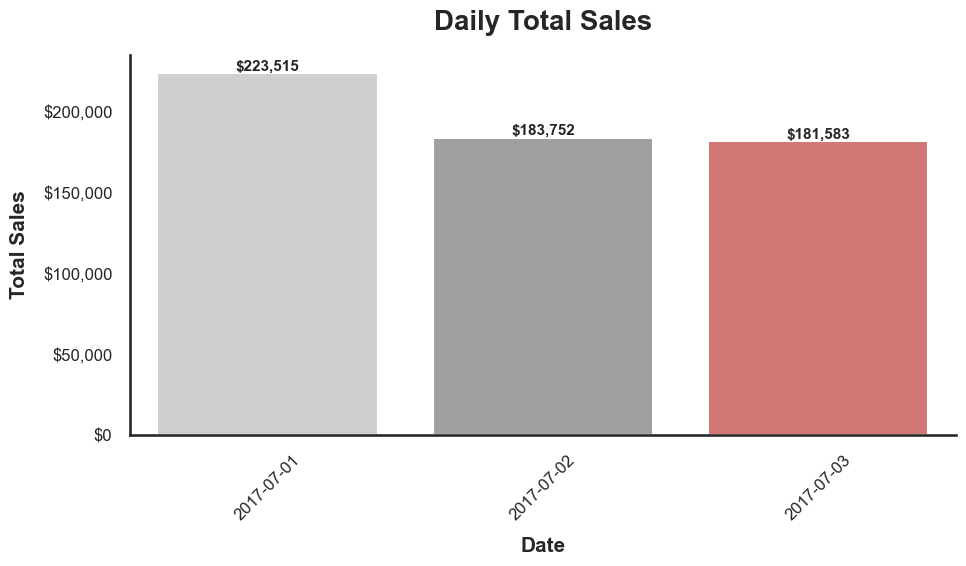

Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\daily_transaction_count.png


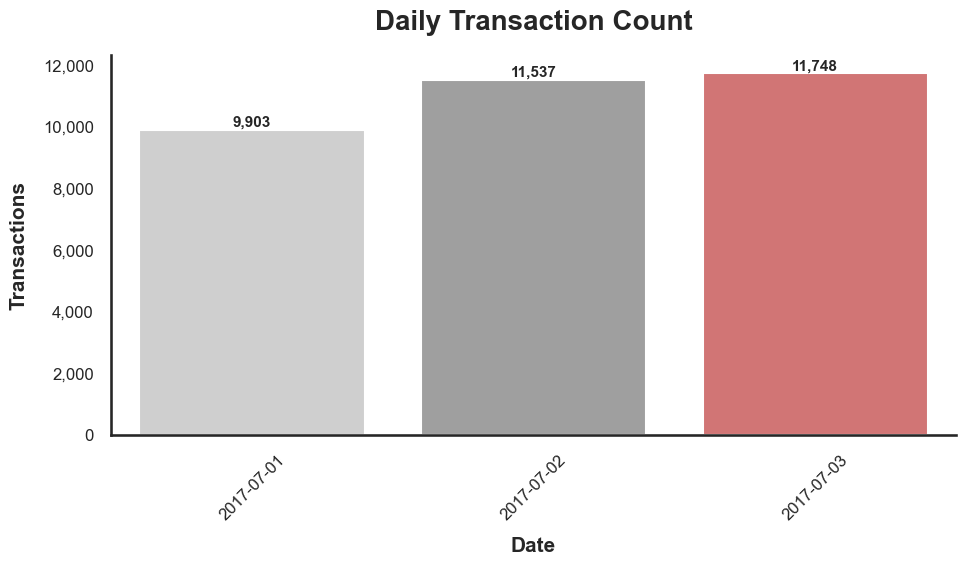

Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\daily_average_order_value.png


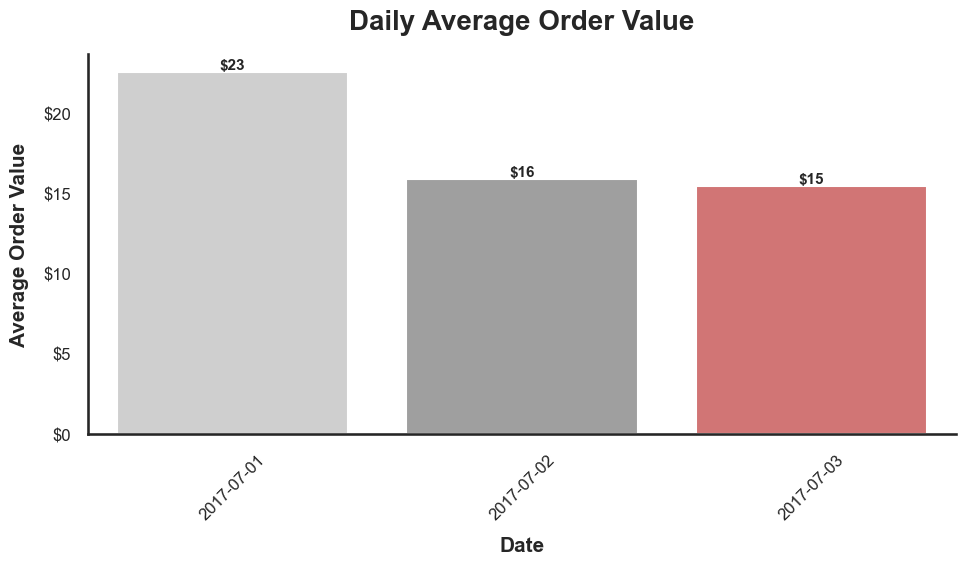

Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\daily_median_order_value.png


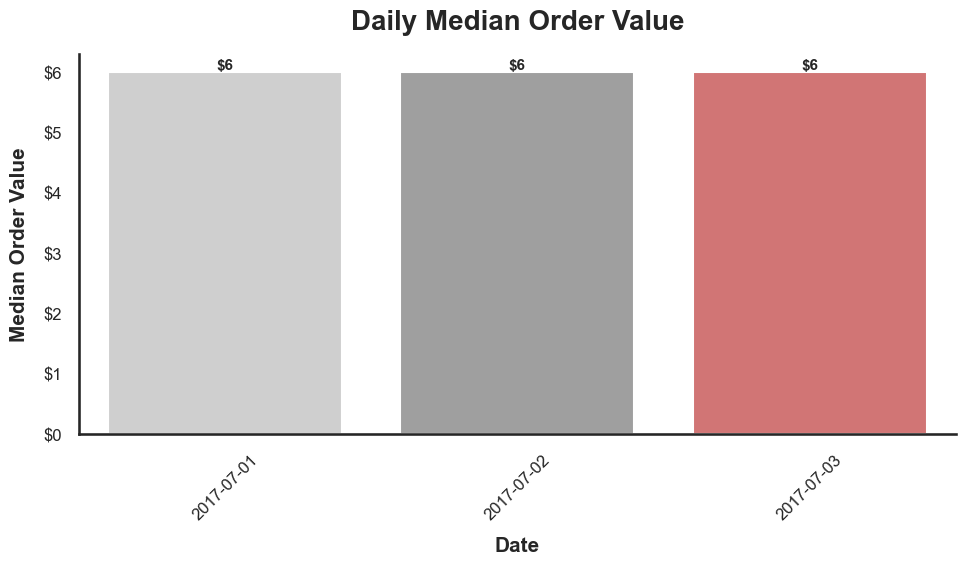

Saved table: c:\Users\melis\Documents\postie-data-science-presentation\outputs\tables\daily_summary.csv


In [208]:
plot_daily_bar(
    data=daily_summary,
    y_col="total_sales",
    title="Daily Total Sales",
    y_label="Total Sales",
    filename="daily_total_sales.png",
    money_axis=True
)

plot_daily_bar(
    data=daily_summary,
    y_col="transactions",
    title="Daily Transaction Count",
    y_label="Transactions",
    filename="daily_transaction_count.png"
)

plot_daily_bar(
    data=daily_summary,
    y_col="average_order_value",
    title="Daily Average Order Value",
    y_label="Average Order Value",
    filename="daily_average_order_value.png",
    money_axis=True
)

plot_daily_bar(
    data=daily_summary,
    y_col="median_order_value",
    title="Daily Median Order Value",
    y_label="Median Order Value",
    filename="daily_median_order_value.png",
    money_axis=True
)

save_table(daily_summary, "daily_summary.csv")

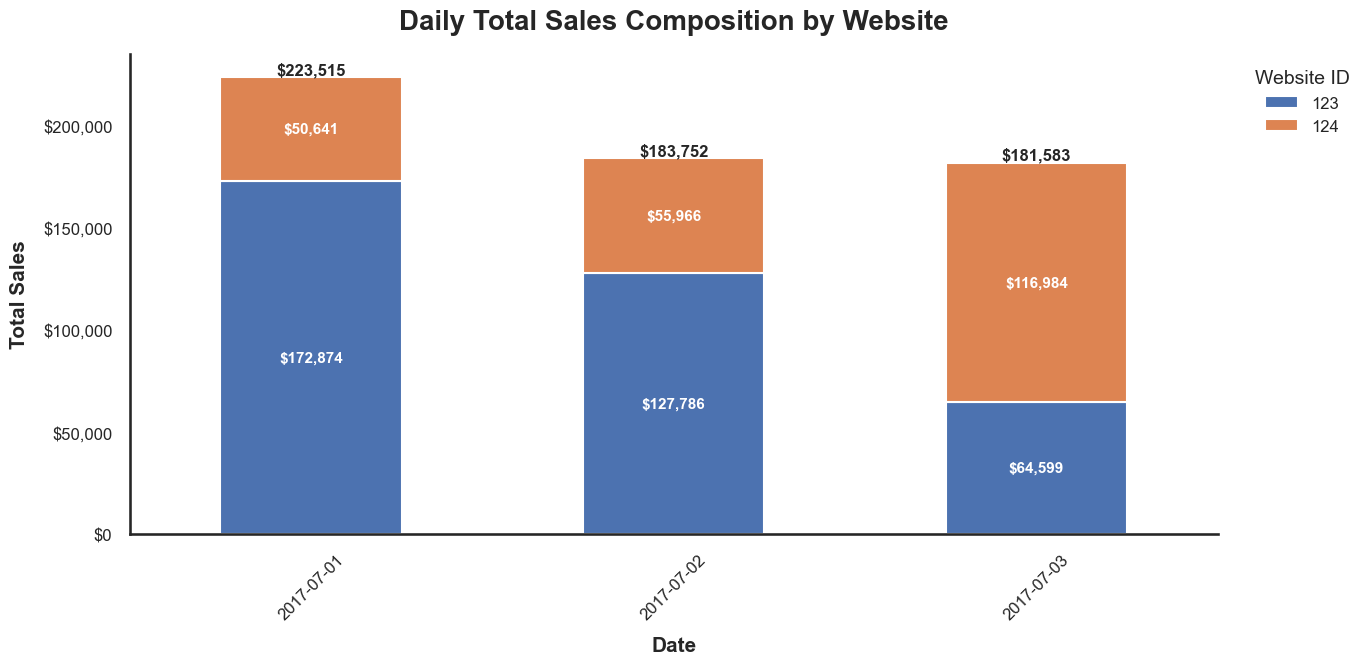

In [209]:
# Summarize sales by date and website
website_daily = (
    df.groupby(["date", "website_id"])
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        unique_customers=("customer_id", "nunique"),
    )
    .reset_index()
    .sort_values(["date", "website_id"])
)


# Create stacked sales table by website
website_sales_pivot = website_daily.pivot_table(
    index="date",
    columns="website_id",
    values="total_sales",
    aggfunc="sum",
    fill_value=0
)

# Clean website IDs for legend
website_sales_pivot.columns = [
    str(int(col)) if pd.notna(col) else str(col)
    for col in website_sales_pivot.columns
]

ax = website_sales_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

# Add white labels inside each website segment
for container in ax.containers:
    labels = [
        f"${value:,.0f}" if value > 0 else ""
        for value in container.datavalues
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

# Add total labels above each stacked bar
daily_totals = website_sales_pivot.sum(axis=1)

for i, total in enumerate(daily_totals):
    ax.text(
        i,
        total,
        f"${total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Daily Total Sales Composition by Website",
    fontsize=20,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Date",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

plt.ylabel(
    "Total Sales",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(False)
sns.despine()

plt.legend(
    title="Website ID",
    title_fontsize=14,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "daily_web.png", dpi=300, bbox_inches="tight")
plt.show()

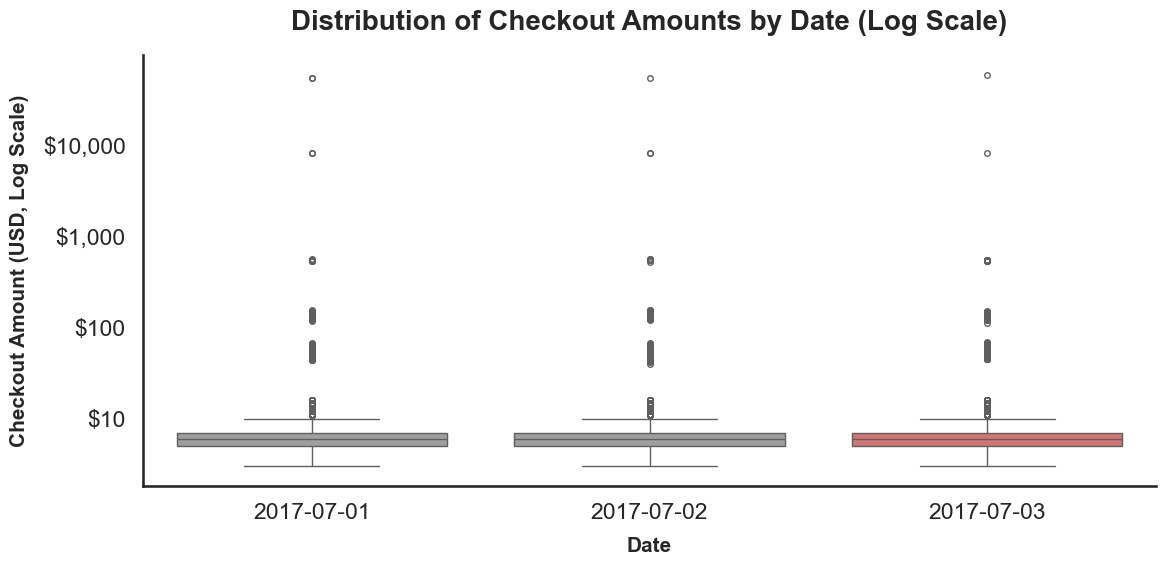

In [210]:
plt.figure(figsize=(12, 6))

# Map x to hue and set legend=False to satisfy the new Seaborn requirements
sns.boxplot(
    data=df, 
    x="date", 
    y="checkout_amount", 
    hue="date",  # <--- Added to map the color palette cleanly
    palette=["#9f9f9f" if d != datetime.date(2017, 7, 3) else "#E06666" for d in sorted(df["date"].unique())],
    legend=False,  # <--- Added to suppress the redundant legend
    fliersize=4
)

plt.yscale("log")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

# Cleaned up plt.title to unpack TITLE_STYLE cleanly without argument conflicts
plt.title("Distribution of Checkout Amounts by Date (Log Scale)", **TITLE_STYLE)
plt.xlabel("Date", **AXIS_LABEL_STYLE)
plt.ylabel("Checkout Amount (USD, Log Scale)", **AXIS_LABEL_STYLE)

# Clean formatting
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

In [211]:
# ------------------------------------------------------------
# Hourly sales and transaction volume by date
# ------------------------------------------------------------

comparison_dates = [
    pd.to_datetime("2017-07-01").date(),
    pd.to_datetime("2017-07-02").date(),
    pd.to_datetime("2017-07-03").date(),
]

hourly_daily = (
    df[df["date"].isin(comparison_dates)]
    .groupby(["date", "hour"])
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        unique_customers=("customer_id", "nunique"),
    )
    .reset_index()
    .sort_values(["date", "hour"])
)

hourly_daily["date_label"] = hourly_daily["date"].astype(str)

save_table(hourly_daily, "hourly_daily_summary.csv")

date_order = sorted(hourly_daily["date"].unique())
date_palette = {
    date: TARGET_COLOR if date == target_date else GREY_COLORS[i % len(GREY_COLORS)]
    for i, date in enumerate(date_order)
}

date_label_palette = {
    str(date): color
    for date, color in date_palette.items()
}
hourly_daily

Saved table: c:\Users\melis\Documents\postie-data-science-presentation\outputs\tables\hourly_daily_summary.csv


,date,hour,transactions,total_sales,average_order_value,unique_customers,date_label
0,2017-07-01,0,237,2258.0,9.527426,235,2017-07-01
1,2017-07-01,1,229,2072.0,9.048035,227,2017-07-01
2,2017-07-01,2,236,1844.0,7.813559,236,2017-07-01
3,2017-07-01,3,253,2609.0,10.312253,251,2017-07-01
4,2017-07-01,4,239,2953.0,12.355649,238,2017-07-01
...,...,...,...,...,...,...,...
67,2017-07-03,19,472,3835.0,8.125000,467,2017-07-03
68,2017-07-03,20,495,5024.0,10.149495,489,2017-07-03
69,2017-07-03,21,503,4868.0,9.677932,496,2017-07-03
70,2017-07-03,22,510,4603.0,9.025490,506,2017-07-03


Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\hourly_sales_by_date.png


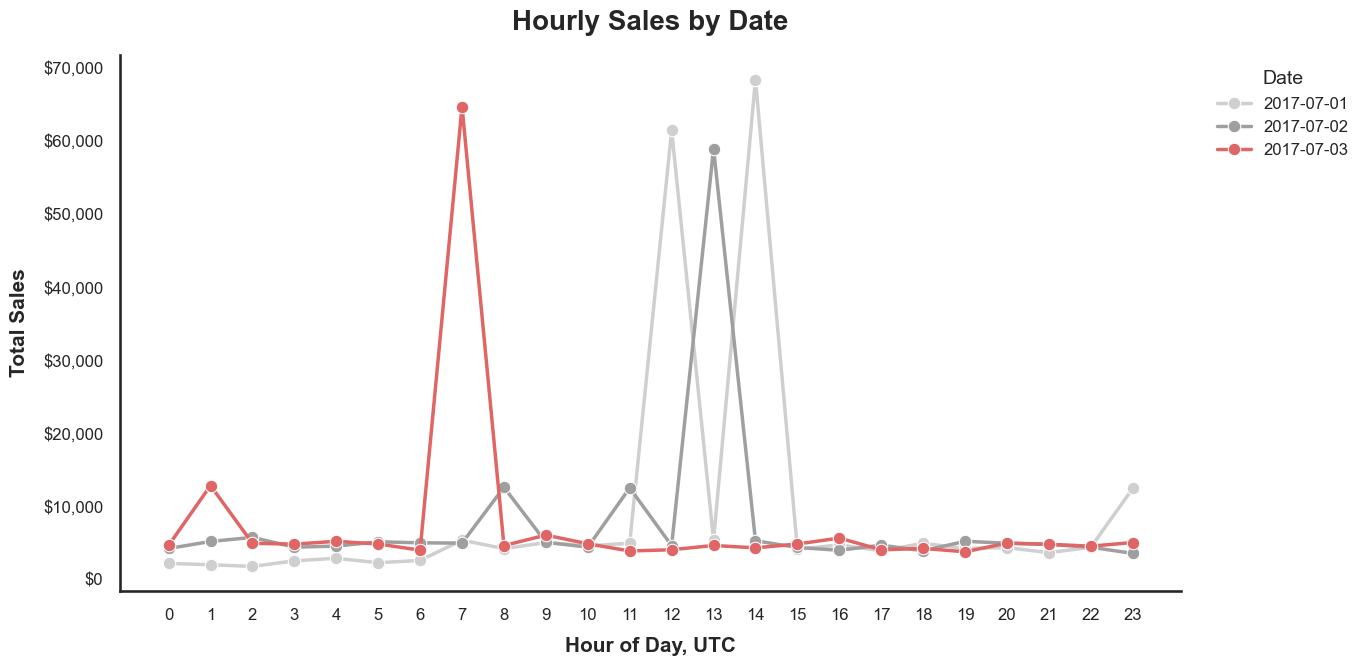

In [212]:
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=hourly_daily,
    x="hour",
    y="total_sales",
    hue="date_label",
    palette=date_label_palette,
    marker="o",
    linewidth=2.5
)

plt.title("Hourly Sales by Date", **TITLE_STYLE)
plt.xlabel("Hour of Day, UTC", **AXIS_LABEL_STYLE)
plt.ylabel("Total Sales", **AXIS_LABEL_STYLE)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.xticks(range(0, 24), fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)
sns.despine()

plt.legend(
    title="Date",
    title_fontsize=14,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
save_current_figure("hourly_sales_by_date.png")
plt.show()

Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\hourly_transactions_by_date.png


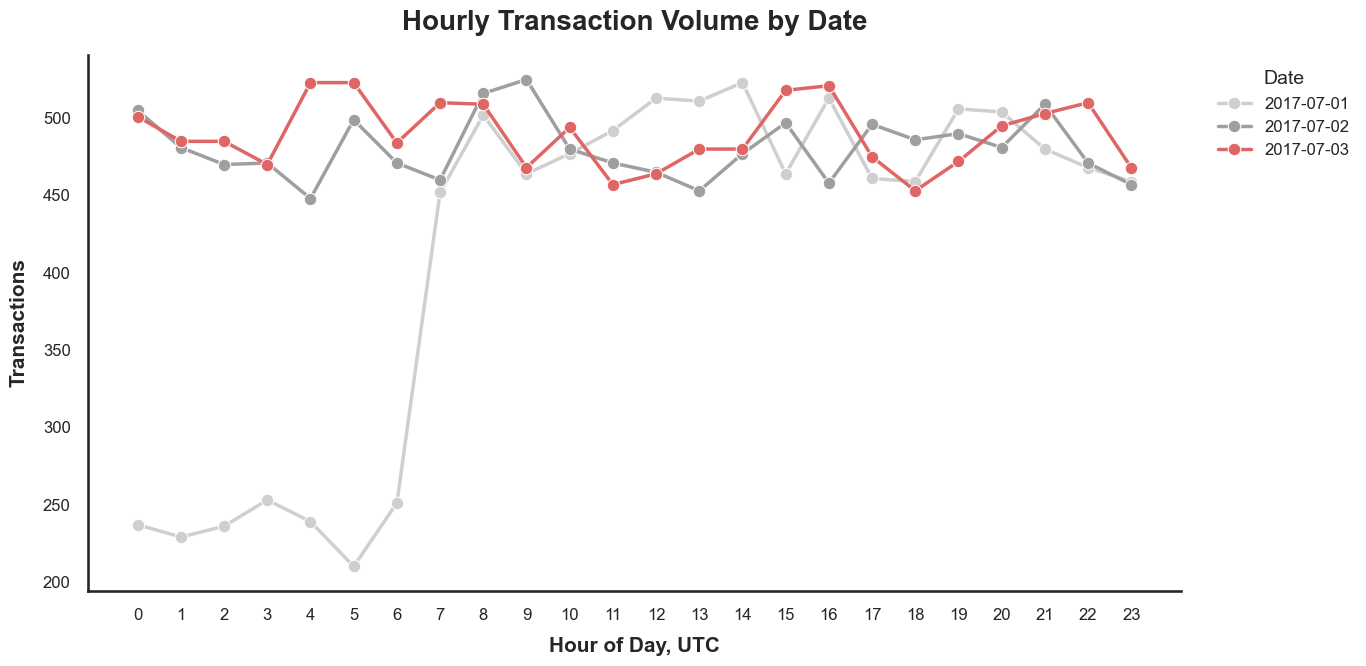

In [213]:
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=hourly_daily,
    x="hour",
    y="transactions",
    hue="date_label",
    palette=date_label_palette,
    marker="o",
    linewidth=2.5
)

plt.title("Hourly Transaction Volume by Date", **TITLE_STYLE)
plt.xlabel("Hour of Day, UTC", **AXIS_LABEL_STYLE)
plt.ylabel("Transactions", **AXIS_LABEL_STYLE)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(range(0, 24), fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)
sns.despine()

plt.legend(
    title="Date",
    title_fontsize=14,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
save_current_figure("hourly_transactions_by_date.png")
plt.show()

Saved figure: c:\Users\melis\Documents\postie-data-science-presentation\outputs\figures\hourly_transactions_by_date_app_version.png


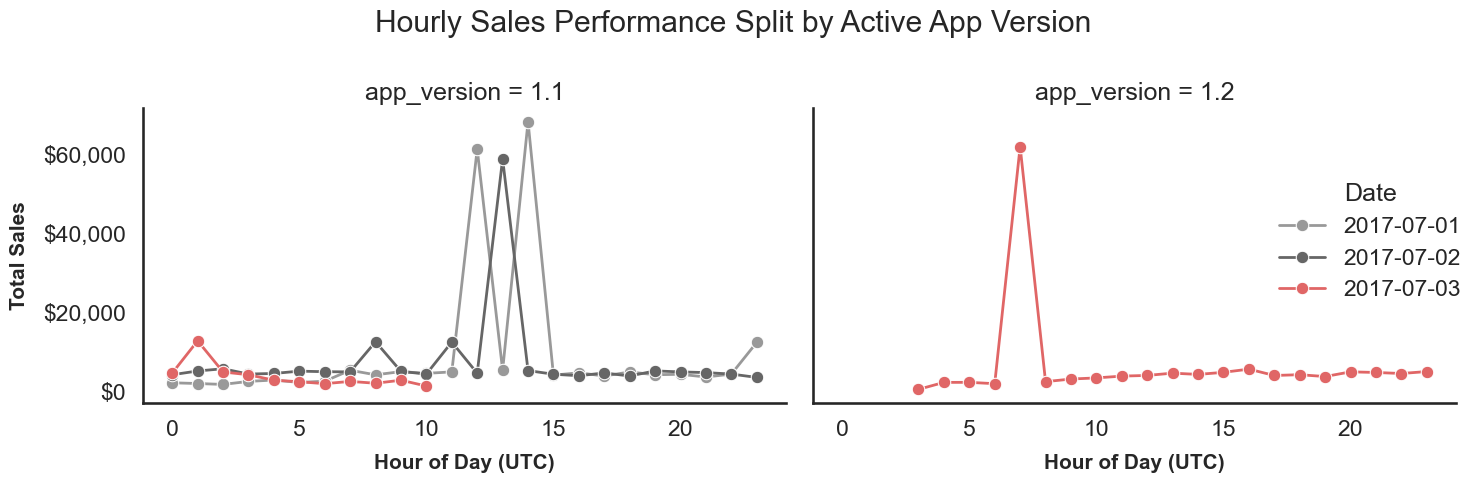

In [214]:
# Filter down to the target comparison dates
comparison_dates = [datetime.date(2017, 7, 1), datetime.date(2017, 7, 2), datetime.date(2017, 7, 3)]
df_filtered = df[df["date"].isin(comparison_dates)].copy()

# Ensure app_version is treated cleanly as a string/categorical feature
df_filtered["app_version"] = df_filtered["app_version"].astype(str)

# Aggregate hourly sales by date and app version
hourly_version = (
    df_filtered.groupby(["date", "hour", "app_version"])["checkout_amount"]
    .sum()
    .reset_index()
)

# Initialize a FacetGrid to split charts by App Version side-by-side
g = sns.FacetGrid(
    hourly_version, 
    col="app_version", 
    hue="date", 
    palette=["#999999", "#666666", "#E06666"], 
    height=5, 
    aspect=1.3,
    sharey=True
)

g.map(sns.lineplot, "hour", "checkout_amount", marker="o", linewidth=2)

# Apply notebook styling across facets
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.set_xlabel("Hour of Day (UTC)", **AXIS_LABEL_STYLE)
    ax.set_ylabel("Total Sales", **AXIS_LABEL_STYLE)
    ax.grid(False)

g.add_legend(title="Date")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Hourly Sales Performance Split by Active App Version")


plt.tight_layout()
save_current_figure("hourly_transactions_by_date_app_version.png")
plt.show()

In [215]:
# ------------------------------------------------------------
# Transaction amount anomaly checks
# ------------------------------------------------------------

amount_anomaly_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "negative_checkout_amounts",
        "zero_checkout_amounts",
        "missing_checkout_amounts",
        "min_checkout_amount",
        "max_checkout_amount",
        "p01_checkout_amount",
        "p50_checkout_amount",
        "p99_checkout_amount",
    ],
    "value": [
        len(df),
        (df["checkout_amount"] < 0).sum(),
        (df["checkout_amount"] == 0).sum(),
        df["checkout_amount"].isna().sum(),
        df["checkout_amount"].min(),
        df["checkout_amount"].max(),
        df["checkout_amount"].quantile(0.01),
        df["checkout_amount"].quantile(0.50),
        df["checkout_amount"].quantile(0.99),
    ]
})

save_table(amount_anomaly_summary, "checkout_amount_anomaly_summary.csv")

amount_anomaly_summary

Saved table: c:\Users\melis\Documents\postie-data-science-presentation\outputs\tables\checkout_amount_anomaly_summary.csv


,metric,value
0,total_rows,33188.0
1,negative_checkout_amounts,17.0
2,zero_checkout_amounts,4.0
3,missing_checkout_amounts,0.0
4,min_checkout_amount,-12.0
5,max_checkout_amount,60000.0
6,p01_checkout_amount,3.0
7,p50_checkout_amount,6.0
8,p99_checkout_amount,66.0


In [216]:
negative_transactions = (
    df[df["checkout_amount"] < 0]
    .sort_values("checkout_amount")
    [[
        "timestamp",
        "date",
        "hour",
        "website_id",
        "customer_id",
        "app_version",
        "checkout_amount",
        "url",
        "source_file",
    ]]
)

save_table(negative_transactions, "negative_checkout_transactions.csv")

negative_transactions

Saved table: c:\Users\melis\Documents\postie-data-science-presentation\outputs\tables\negative_checkout_transactions.csv


,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,url,source_file
23435,2017-07-03 00:27:19+00:00,2017-07-03,0,124,10678,1.1,-12.0,http://xyz.com/checkout?European+Grape=1&Round...,2017-07-03.csv
23878,2017-07-03 08:20:25+00:00,2017-07-03,8,124,10113,1.1,-12.0,http://xyz.com/checkout?Bignay=2,2017-07-03.csv
23957,2017-07-03 01:28:04+00:00,2017-07-03,1,124,10186,1.1,-12.0,http://xyz.com/checkout?Ume=1&Natal+Orange=1,2017-07-03.csv
24695,2017-07-03 10:01:08+00:00,2017-07-03,10,123,10769,1.1,-12.0,http://www.example.com/store/?Round+Kumquat=1&...,2017-07-03.csv
24744,2017-07-03 03:10:05+00:00,2017-07-03,3,124,10152,1.1,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Black%...,2017-07-03.csv
25291,2017-07-03 11:15:33+00:00,2017-07-03,11,124,10906,1.2,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Black%...,2017-07-03.csv
25320,2017-07-03 11:18:54+00:00,2017-07-03,11,124,10187,1.2,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Ylang-...,2017-07-03.csv
25473,2017-07-03 04:37:32+00:00,2017-07-03,4,123,10814,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&Euro...,2017-07-03.csv
25534,2017-07-03 11:44:53+00:00,2017-07-03,11,124,10098,1.2,-12.0,http://xyz.com/checkout?Natal+Orange=2,2017-07-03.csv
25745,2017-07-03 05:10:47+00:00,2017-07-03,5,123,10462,1.2,-12.0,http://store.example.com/?Hazelnut=1&Mabolo=1,2017-07-03.csv


In [217]:
# ------------------------------------------------------------
# Source file completeness validation
# ------------------------------------------------------------

source_file_summary = (
    df.groupby("source_file")
    .agg(
        rows=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        timestamp_min=("timestamp", "min"),
        timestamp_max=("timestamp", "max"),
        missing_timestamps=("timestamp", lambda x: x.isna().sum()),
        missing_checkout_amounts=("checkout_amount", lambda x: x.isna().sum()),
        unique_websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
    )
    .reset_index()
)

save_table(source_file_summary, "source_file_summary.csv")

source_file_summary

Saved table: c:\Users\melis\Documents\postie-data-science-presentation\outputs\tables\source_file_summary.csv


,source_file,rows,total_sales,timestamp_min,timestamp_max,missing_timestamps,missing_checkout_amounts,unique_websites,app_versions
0,2017-07-01.csv,11634,241491.0,2017-07-01 00:00:15+00:00,2017-07-02 07:00:35+00:00,0,0,2,1
1,2017-07-02.csv,11573,183294.0,2017-07-02 00:00:51+00:00,2017-07-03 06:59:58+00:00,0,0,2,1
2,2017-07-03.csv,9981,164065.0,2017-07-03 00:00:24+00:00,2017-07-03 23:59:57+00:00,0,0,2,2
